In [29]:
# set up environment
import sys
import json
import re
import requests
import pandas as pd
from pathlib import Path
import json
import csv
from caveclient import CAVEclient
import urllib.parse
#pip install neuprint-python
from neuprint import Client, fetch_neurons, fetch_custom, NeuronCriteria as NC


print("Python executable:", sys.executable)
print("Imports OK")

Python executable: c:\Users\JHS\Documents\Python\cave_env\Scripts\python.exe
Imports OK


## set up paths and directories

In [30]:
# set up directories
PROJECT_ROOT = Path.cwd() #anchor to current notebook location

TABLES_DIR = Path(r"C:\Users\JHS\Documents\Python\project_folder_4B\analysis_MANC v1.2.3_04B_cross_neuromeres\neuromere_tables")

OUTPUT_DIR = TABLES_DIR.parent / "meta_analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Output dir :", OUTPUT_DIR)

Tables dir : C:\Users\JHS\Documents\Python\project_folder_4B\analysis_MANC v1.2.3_04B_cross_neuromeres\neuromere_tables
Output dir : C:\Users\JHS\Documents\Python\project_folder_4B\analysis_MANC v1.2.3_04B_cross_neuromeres\meta_analysis_outputs


## Inspect CSV

In [32]:
# Retreive CSV files, load
csv_paths = sorted(TABLES_DIR.glob("*.csv"))

print("Found CSV files:")
for p in csv_paths:
    print(" -", p.name)

print(f"\nTotal CSVs found: {len(csv_paths)}")

Found CSV files:
 - Classification_04B_T2L.csv
 - Classification_04B_T2R.csv

Total CSVs found: 2


## read all CSVs into a dictionary

In [ ]:
dfs_by_neuromere = {}

for path in csv_paths:
    df = pd.read_csv(path)

    # infer neuromere from filename if needed
    # but better to trust the column if it exists
    if "neuromere" not in df.columns:
        raise ValueError(f"'neuromere' column missing in {path.name}")

    neuromere = df["neuromere"].dropna().unique()
    if len(neuromere) != 1:
        raise ValueError(f"Expected exactly 1 neuromere in {path.name}, found: {neuromere}")

    neuromere = neuromere[0] #later adjust to read other neuromere tables, now just pick the first (0)
    dfs_by_neuromere[neuromere] = df

print("Loaded neuromere tables:")
for neuromere, df in dfs_by_neuromere.items():
    print(neuromere, df.shape)

Loaded neuromere tables:
T2L (92, 18)
T2R (95, 18)


## concatenate into one dataframe 

In [6]:
pooled_df = pd.concat(dfs_by_neuromere.values(), ignore_index=True)

print("Pooled shape:", pooled_df.shape)
#pooled_df.head()

Pooled shape: (187, 18)


## Basic checks

In [8]:
print("Columns:")
print(sorted(pooled_df.columns.tolist()))

print("\nNeuromeres:")
print(pooled_df["neuromere"].value_counts(dropna=False))

print("\nMajor classes:")
print(pooled_df["major_class"].value_counts(dropna=False))

print("\nMissing values:")
print(pooled_df.isna().sum())

#save pooled dataframe 

pooled_out = OUTPUT_DIR / "pooled_all_neuromeres_classification_04B.csv"
pooled_df.to_csv(pooled_out, index=False)

print("Saved pooled dataframe to:")
print(pooled_out)

Columns:
['birthtime', 'bodyId', 'class', 'group_var', 'hemilineage', 'instance', 'legacy_tag', 'longTract', 'major_class', 'morphology_cluster', 'morphology_cluster_id', 'neuromere', 'rootSide', 'somaNeuromere', 'somaSide', 'subclass', 'subclass_level1', 'type']

Neuromeres:
neuromere
T2R    95
T2L    92
Name: count, dtype: int64

Major classes:
major_class
IR    112
BR     55
II      8
BI      6
IA      6
Name: count, dtype: int64

Missing values:
neuromere                  0
bodyId                     0
group_var                  0
major_class                0
subclass_level1            0
morphology_cluster         0
morphology_cluster_id      0
legacy_tag                75
type                       0
instance                   0
class                      0
subclass                   0
hemilineage                0
somaNeuromere              0
somaSide                   0
rootSide                 181
longTract                181
birthtime                  0
dtype: int64
Saved poole

# meta analysis (compare clusters between neuromeres)

In [9]:
## counts by neuromere and major classes
summary_major_class = (
    pooled_df.groupby(["neuromere", "major_class"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
    .sort_values(["neuromere", "major_class"])
)

summary_major_class

,neuromere,major_class,n_cells
0,T2L,BI,3
1,T2L,BR,27
2,T2L,IA,3
3,T2L,II,4
4,T2L,IR,55
5,T2R,BI,3
6,T2R,BR,28
7,T2R,IA,3
8,T2R,II,4
9,T2R,IR,57


## counts by morphology cluster ID across neuromeres

In [10]:
summary_cluster = (
    pooled_df.groupby(["neuromere", "morphology_cluster_id"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
    .sort_values(["morphology_cluster_id", "neuromere"])
)

summary_cluster.head(50)

,neuromere,morphology_cluster_id,n_cells
0,T2L,BI_1_1,3
17,T2R,BI_1_1,3
1,T2L,BR_1_1,27
18,T2R,BR_1_1,28
2,T2L,IA_1_1,3
19,T2R,IA_1_1,3
3,T2L,II_1_1,4
20,T2R,II_1_1,4
4,T2L,IR_1_1,5
21,T2R,IR_1_1,2


## export summaries

In [12]:
summary_major_class.to_csv(OUTPUT_DIR / "summary_major_class_by_neuromere.csv", index=False)
summary_cluster.to_csv(OUTPUT_DIR / "summary_morphology_cluster_by_neuromere.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "comparison_morphology_clusters_across_neuromeres.csv", index=False)

print("Saved summary tables.")

Saved summary tables.


## graphs from pooled CSV 

In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt ## in venv
TABLES_DIR = Path(r"C:\Users\JHS\Documents\Python\project_folder_4B\analysis_MANC v1.2.3_04B_cross_neuromeres\neuromere_tables")

csv_paths = sorted(TABLES_DIR.glob("Classification_04B_*.csv"))

dfs = [pd.read_csv(p) for p in csv_paths]
pooled_df = pd.concat(dfs, ignore_index=True)

print(pooled_df.shape)
#pooled_df.head()

(187, 18)


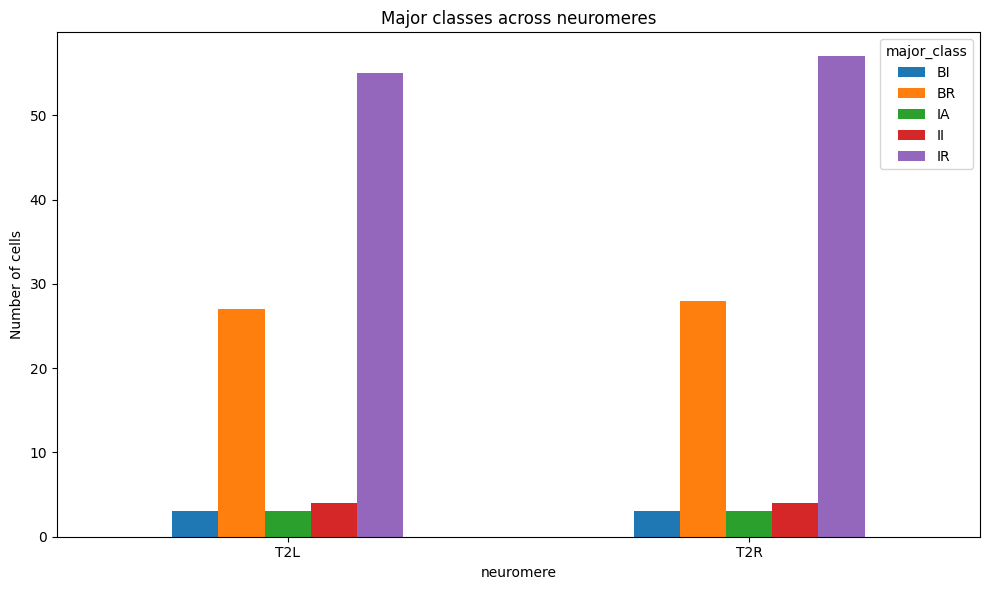

In [18]:
summary_major = (
    pooled_df.groupby(["neuromere", "major_class"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
)

plot_df = summary_major.pivot(
    index="neuromere",
    columns="major_class",
    values="n_cells"
).fillna(0)

plot_df.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Number of cells")
plt.title("Major classes across neuromeres")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### morphology across neuromeres

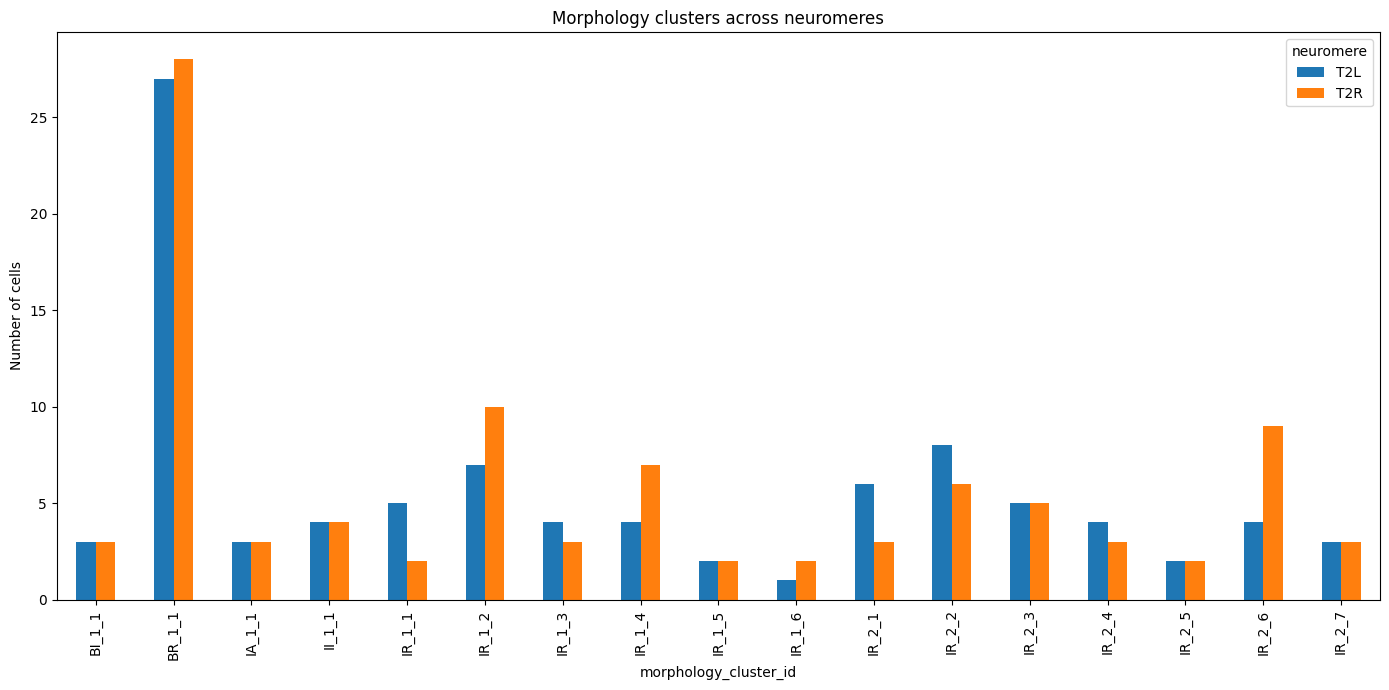

In [19]:
summary_cluster = (
    pooled_df.groupby(["morphology_cluster_id", "neuromere"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
)

cluster_plot_df = summary_cluster.pivot(
    index="morphology_cluster_id",
    columns="neuromere",
    values="n_cells"
).fillna(0)

cluster_plot_df.plot(kind="bar", figsize=(14, 7))
plt.ylabel("Number of cells")
plt.title("Morphology clusters across neuromeres")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

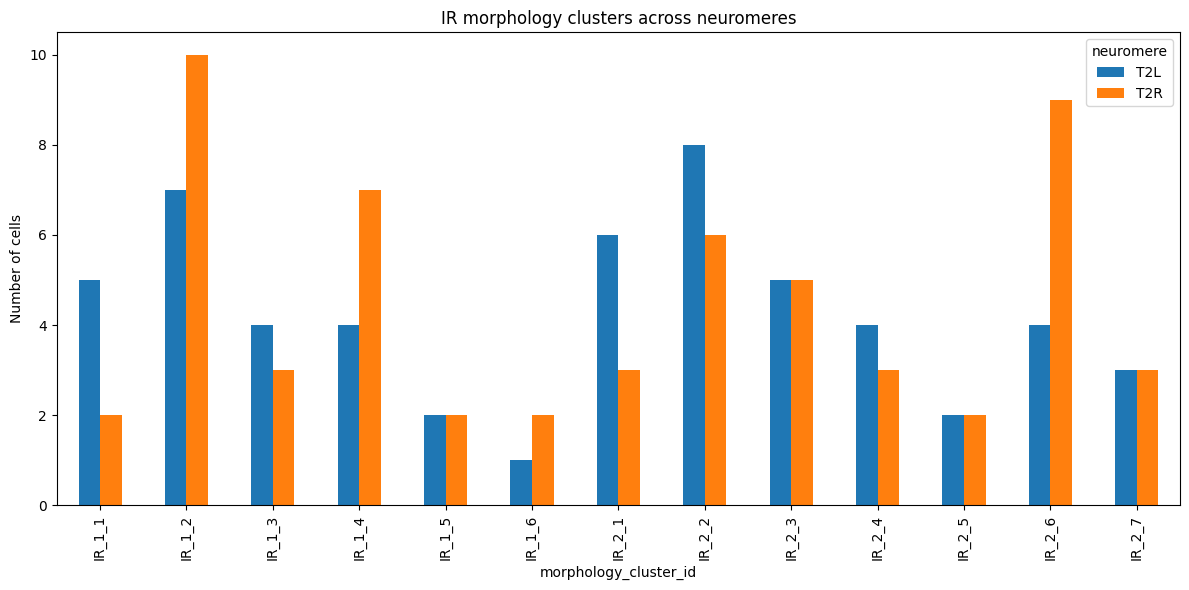

In [20]:
#### focussing on IR only 
ir_df = pooled_df[pooled_df["major_class"] == "IR"].copy()

ir_summary = (
    ir_df.groupby(["morphology_cluster_id", "neuromere"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
)

ir_plot_df = ir_summary.pivot(
    index="morphology_cluster_id",
    columns="neuromere",
    values="n_cells"
).fillna(0)

ir_plot_df.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Number of cells")
plt.title("IR morphology clusters across neuromeres")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

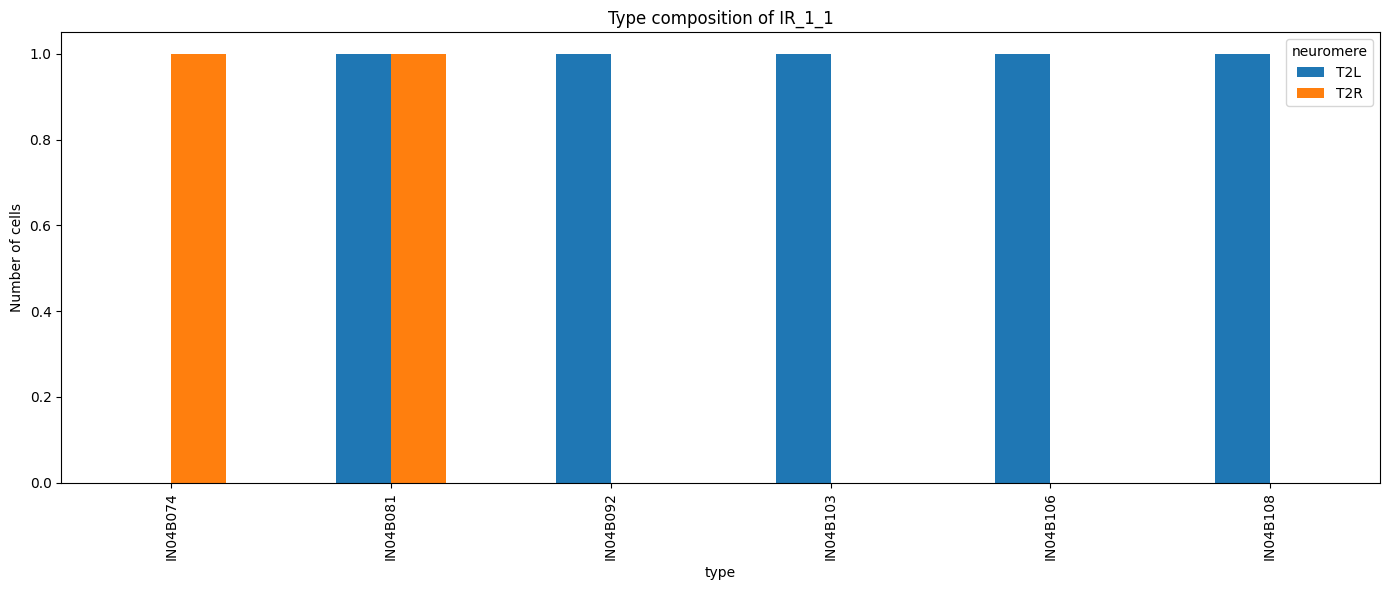

In [21]:
#### comparison within one cluster 
cluster_of_interest = "IR_1_1"

cluster_type_summary = (
    pooled_df[pooled_df["morphology_cluster_id"] == cluster_of_interest]
    .groupby(["type", "neuromere"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
)

cluster_type_plot_df = cluster_type_summary.pivot(
    index="type",
    columns="neuromere",
    values="n_cells"
).fillna(0)

cluster_type_plot_df.plot(kind="bar", figsize=(14, 6))
plt.ylabel("Number of cells")
plt.title(f"Type composition of {cluster_of_interest}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

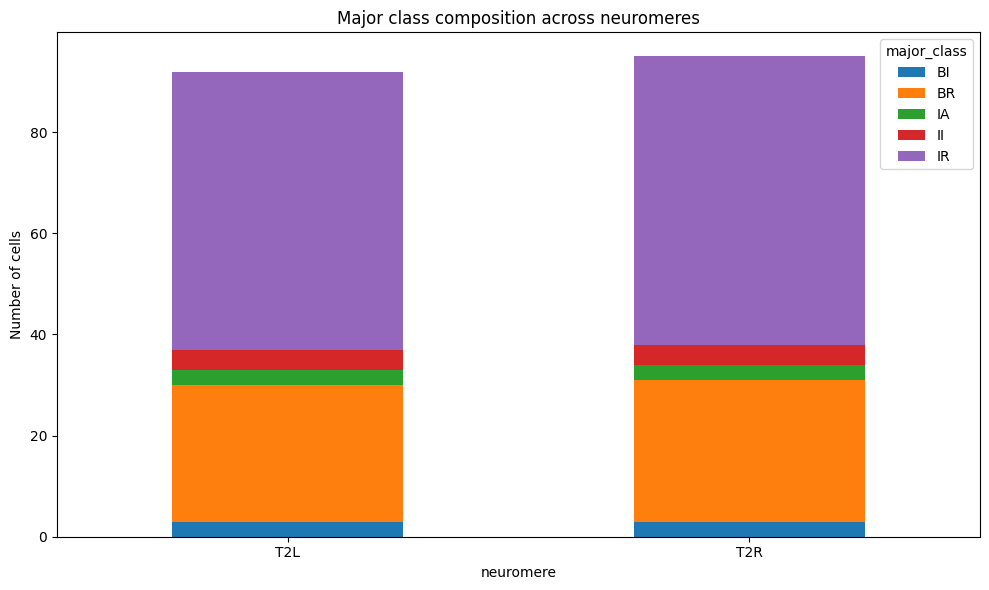

In [22]:
#### stacked view of proportions
plot_df.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.ylabel("Number of cells")
plt.title("Major class composition across neuromeres")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

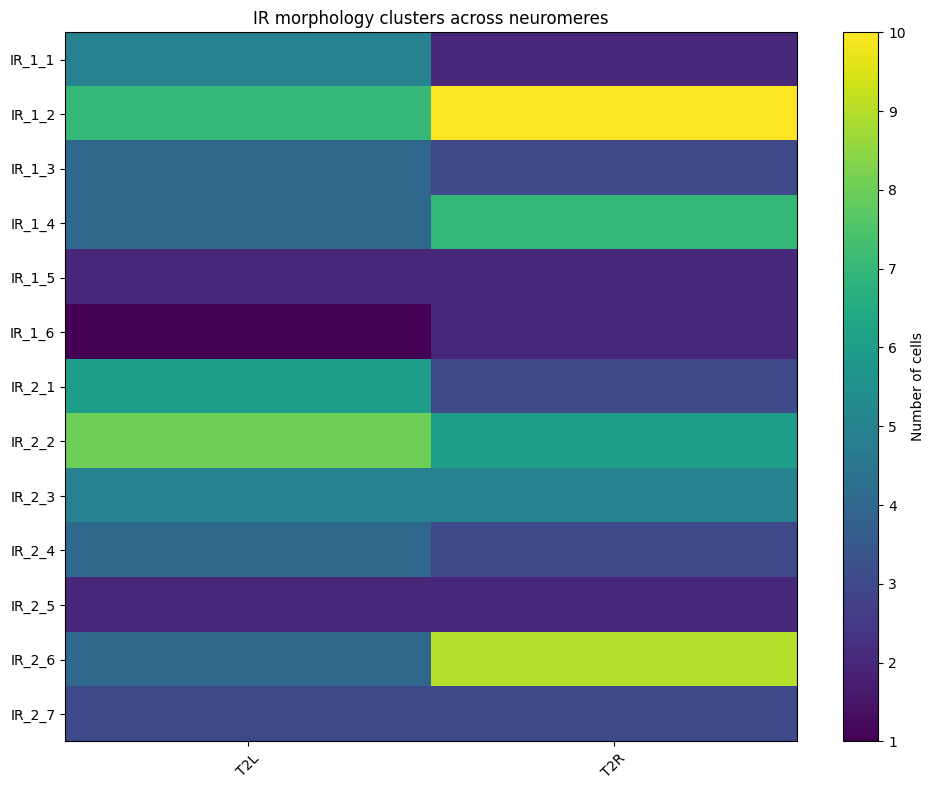

In [23]:
#### heatmap style view
plt.figure(figsize=(10, 8))
plt.imshow(ir_plot_df.values, aspect="auto")
plt.colorbar(label="Number of cells")
plt.xticks(range(len(ir_plot_df.columns)), ir_plot_df.columns, rotation=45)
plt.yticks(range(len(ir_plot_df.index)), ir_plot_df.index)
plt.title("IR morphology clusters across neuromeres")
plt.tight_layout()
plt.show()

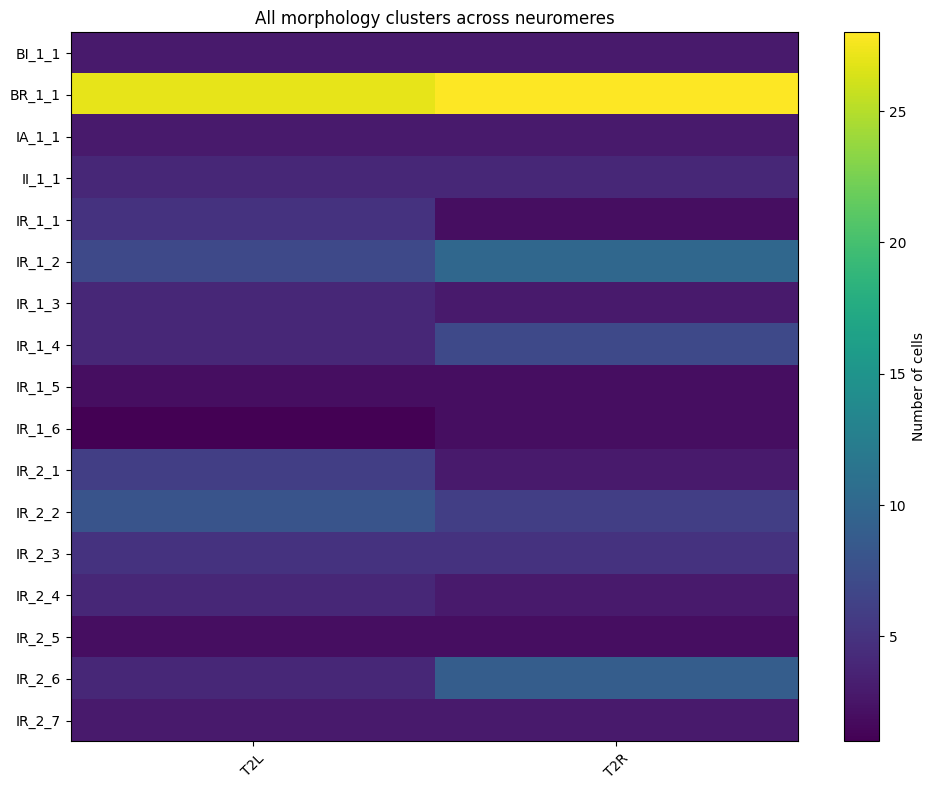

TypeError: imshow() missing 1 required positional argument: 'X'

In [ ]:
## heatmap for all clusters, not IR only

### build full cluster table 
summary_cluster = (
    pooled_df.groupby(["morphology_cluster_id", "neuromere"])["bodyId"]
    .nunique()
    .reset_index(name="n_cells")
)

cluster_plot_df = summary_cluster.pivot(
    index="morphology_cluster_id",
    columns="neuromere",
    values="n_cells"
).fillna(0)


cluster_plot_df = cluster_plot_df.sort_index(
    key=lambda x: x.str.split("_").str[0]
)


# sort it cleanly
cluster_plot_df = cluster_plot_df.sort_index()

## plot heatmap 
plt.figure(figsize=(10, 8))
plt.imshow(cluster_plot_df.values, aspect="auto")

plt.colorbar(label="Number of cells")

plt.xticks(
    range(len(cluster_plot_df.columns)),
    cluster_plot_df.columns,
    rotation=45
)

plt.yticks(
    range(len(cluster_plot_df.index)),
    cluster_plot_df.index
)

plt.title("All morphology clusters across neuromeres")
plt.tight_layout()
plt.show()


In [24]:
## save data behind the plots
OUTPUT_DIR = TABLES_DIR.parent / "meta_analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_major.to_csv(OUTPUT_DIR / "summary_major_class_by_neuromere.csv", index=False)
summary_cluster.to_csv(OUTPUT_DIR / "summary_morphology_cluster_by_neuromere.csv", index=False)
ir_summary.to_csv(OUTPUT_DIR / "summary_IR_clusters_by_neuromere.csv", index=False)
